In [1]:
!pip install mlflow

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_curve,roc_auc_score,precision_score,recall_score,f1_score
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import RandomOverSampler
import mlflow


In [3]:
df = pd.read_csv("Banking_Card_Transaction_Fraud.csv")

In [4]:
df

,transaction_id,transaction_datetime,transaction_amount_inr,transaction_channel,merchant_category,customer_region,device_type,account_age_months,available_balance_inr,monthly_income_inr,credit_limit_inr,credit_utilization_pct,transactions_last_24h,avg_transaction_amount_30d_inr,failed_logins_last_24h,distance_from_usual_location_km,international_transaction,card_present,prior_disputes_12m,is_fraud
0,TXN000001,2025-04-19 13:36:00,1294.46,mobile_app,NaN,Hyderabad,card_terminal,59,56324.23,18170.53,66264.80,60.6,4,1897.78,0,13.1,1,0,0,0
1,TXN000002,2025-05-23 18:58:00,956.35,ATM,cash_withdrawal,Other,card_terminal,129,180262.98,64345.05,117417.29,61.3,1,1311.76,2,17.1,0,1,0,0
2,TXN000003,2025-11-17 08:55:00,1576.45,mobile_app,restaurants,Mumbai,Android,34,63690.93,61944.55,174783.14,37.7,3,2525.18,3,33.3,0,0,2,0
3,TXN000004,2025-01-30 04:24:00,3467.67,mobile_app,fuel,Bengaluru,Android,81,19233.57,37814.77,142356.37,15.0,1,1725.23,4,10.0,0,0,0,0
4,TXN000005,2025-09-03 04:04:00,3302.44,POS,fuel,Chennai,iOS,10,17519.74,78127.35,122304.21,52.3,1,4726.21,0,NaN,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,TXN009996,2025-09-29 05:25:00,2592.65,mobile_app,fuel,Mumbai,card_terminal,32,260113.19,68565.60,235031.84,3.1,0,NaN,0,50.5,0,0,0,0
9996,TXN009997,2025-05-06 17:55:00,2093.29,POS,utilities,Delhi,NaN,15,80627.05,NaN,87996.41,48.8,1,2121.68,2,71.4,0,1,0,0
9997,TXN009998,2025-04-16 05:38:00,6966.57,mobile_app,utilities,Chennai,Android,133,571189.37,144358.16,473979.26,22.6,4,2417.57,0,33.1,0,0,0,0
9998,TXN009999,2025-05-01 12:17:00,1493.50,POS,groceries,Delhi,iOS,32,424304.65,208425.13,836294.09,41.5,4,817.13,0,49.3,0,1,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   transaction_id                   10000 non-null  str    
 1   transaction_datetime             10000 non-null  str    
 2   transaction_amount_inr           10000 non-null  float64
 3   transaction_channel              10000 non-null  str    
 4   merchant_category                9570 non-null   str    
 5   customer_region                  9680 non-null   str    
 6   device_type                      9475 non-null   str    
 7   account_age_months               10000 non-null  int64  
 8   available_balance_inr            9306 non-null   float64
 9   monthly_income_inr               8876 non-null   float64
 10  credit_limit_inr                 9648 non-null   float64
 11  credit_utilization_pct           9303 non-null   float64
 12  transactions_last_24h         

In [6]:
print(df.shape)
df.isna().sum()

(10000, 20)


transaction_id                        0
transaction_datetime                  0
transaction_amount_inr                0
transaction_channel                   0
merchant_category                   430
customer_region                     320
device_type                         525
account_age_months                    0
available_balance_inr               694
monthly_income_inr                 1124
credit_limit_inr                    352
credit_utilization_pct              697
transactions_last_24h                 0
avg_transaction_amount_30d_inr      830
failed_logins_last_24h                0
distance_from_usual_location_km    1163
international_transaction             0
card_present                          0
prior_disputes_12m                    0
is_fraud                              0
dtype: int64

In [ ]:
missing_percentage = (df.isna().sum() / len(df)) * 100
missing_percentage    

transaction_id                      0.00
transaction_datetime                0.00
transaction_amount_inr              0.00
transaction_channel                 0.00
merchant_category                   4.30
customer_region                     3.20
device_type                         5.25
account_age_months                  0.00
available_balance_inr               6.94
monthly_income_inr                 11.24
credit_limit_inr                    3.52
credit_utilization_pct              6.97
transactions_last_24h               0.00
avg_transaction_amount_30d_inr      8.30
failed_logins_last_24h              0.00
distance_from_usual_location_km    11.63
international_transaction           0.00
card_present                        0.00
prior_disputes_12m                  0.00
is_fraud                            0.00
dtype: float64

In [8]:
df["transaction_datetime"] = pd.to_datetime(df["transaction_datetime"])

In [9]:
df.describe()

,transaction_datetime,transaction_amount_inr,account_age_months,available_balance_inr,monthly_income_inr,credit_limit_inr,credit_utilization_pct,transactions_last_24h,avg_transaction_amount_30d_inr,failed_logins_last_24h,distance_from_usual_location_km,international_transaction,card_present,prior_disputes_12m,is_fraud
count,10000,10000.000000,10000.000000,9.306000e+03,8876.000000,9.648000e+03,9303.000000,10000.000000,9170.000000,10000.000000,8837.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2025-07-02 03:37:31.326000,4351.418364,89.691200,1.411243e+05,69004.248162,1.769877e+05,44.012276,3.091500,2291.996640,0.613100,55.941157,0.078000,0.428700,0.186900,0.060000
min,2025-01-01 00:13:00,50.000000,1.000000,1.559060e+03,12000.000000,2.000000e+04,2.000000,0.000000,119.880000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2025-03-31 14:47:30,946.412500,45.000000,5.591131e+04,41223.275000,8.616444e+04,27.700000,0.000000,1208.412500,0.000000,8.300000,0.000000,0.000000,0.000000,0.000000
50%,2025-07-02 13:57:00,1923.210000,89.000000,1.088099e+05,59495.535000,1.417277e+05,43.100000,2.000000,1861.875000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000
75%,2025-09-30 03:09:00,3841.967500,134.000000,1.899910e+05,85837.950000,2.287785e+05,59.600000,4.000000,2895.082500,1.000000,40.400000,0.000000,1.000000,0.000000,0.000000
max,2025-12-31 23:00:00,819855.390000,180.000000,1.226622e+06,605145.270000,1.492824e+06,97.600000,31.000000,18389.540000,6.000000,2247.400000,1.000000,1.000000,3.000000,1.000000
std,NaN,16461.444466,51.838618,1.223735e+05,40489.300448,1.312605e+05,20.848275,3.774487,1618.025048,1.259511,203.057403,0.268185,0.494915,0.533851,0.237499


In [10]:
df["is_fraud"].value_counts()

is_fraud
0    9400
1     600
Name: count, dtype: int64

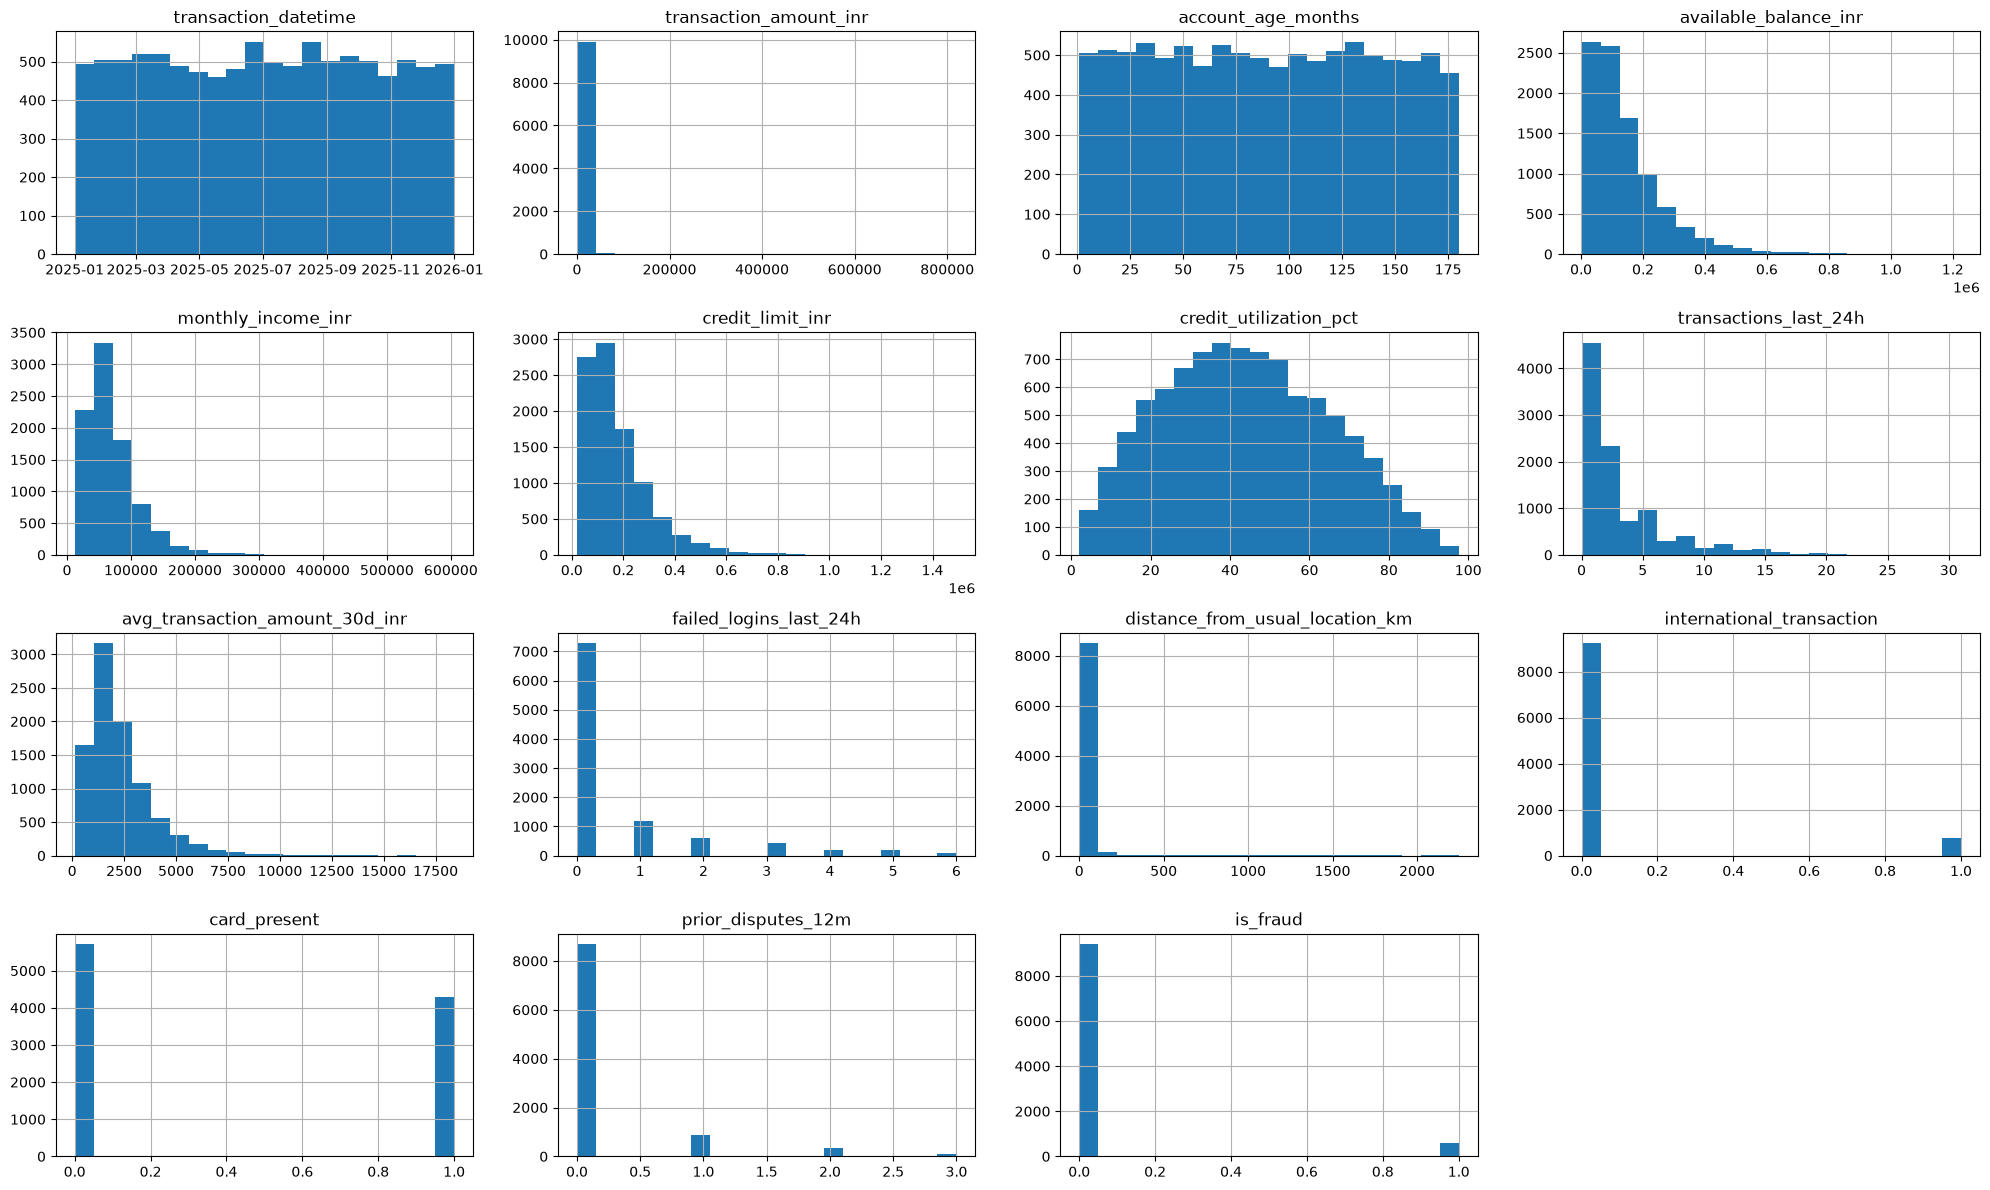

In [11]:
df.hist(figsize=(20,12),bins=20)
plt.tight_layout()
plt.show()

In [12]:
df["transaction_amount_inr"] = np.log1p(df["transaction_amount_inr"])
df["monthly_income_inr"] = np.log1p(df["monthly_income_inr"])
df["available_balance_inr"] = np.log1p(df["available_balance_inr"])
df["credit_limit_inr"] = np.log1p(df["credit_limit_inr"])
df["transaction_amount_inr"] = np.log1p(df["transaction_amount_inr"])

df["transactions_last_24h"] = np.log1p(df["transactions_last_24h"])
df["avg_transaction_amount_30d_inr"] = np.log1p(df["avg_transaction_amount_30d_inr"])
df["failed_logins_last_24h"] = np.log1p(df["failed_logins_last_24h"])

df["distance_from_usual_location_km"] = np.log1p(df["distance_from_usual_location_km"])
df["failed_logins_last_24h"] = np.log1p(df["failed_logins_last_24h"])



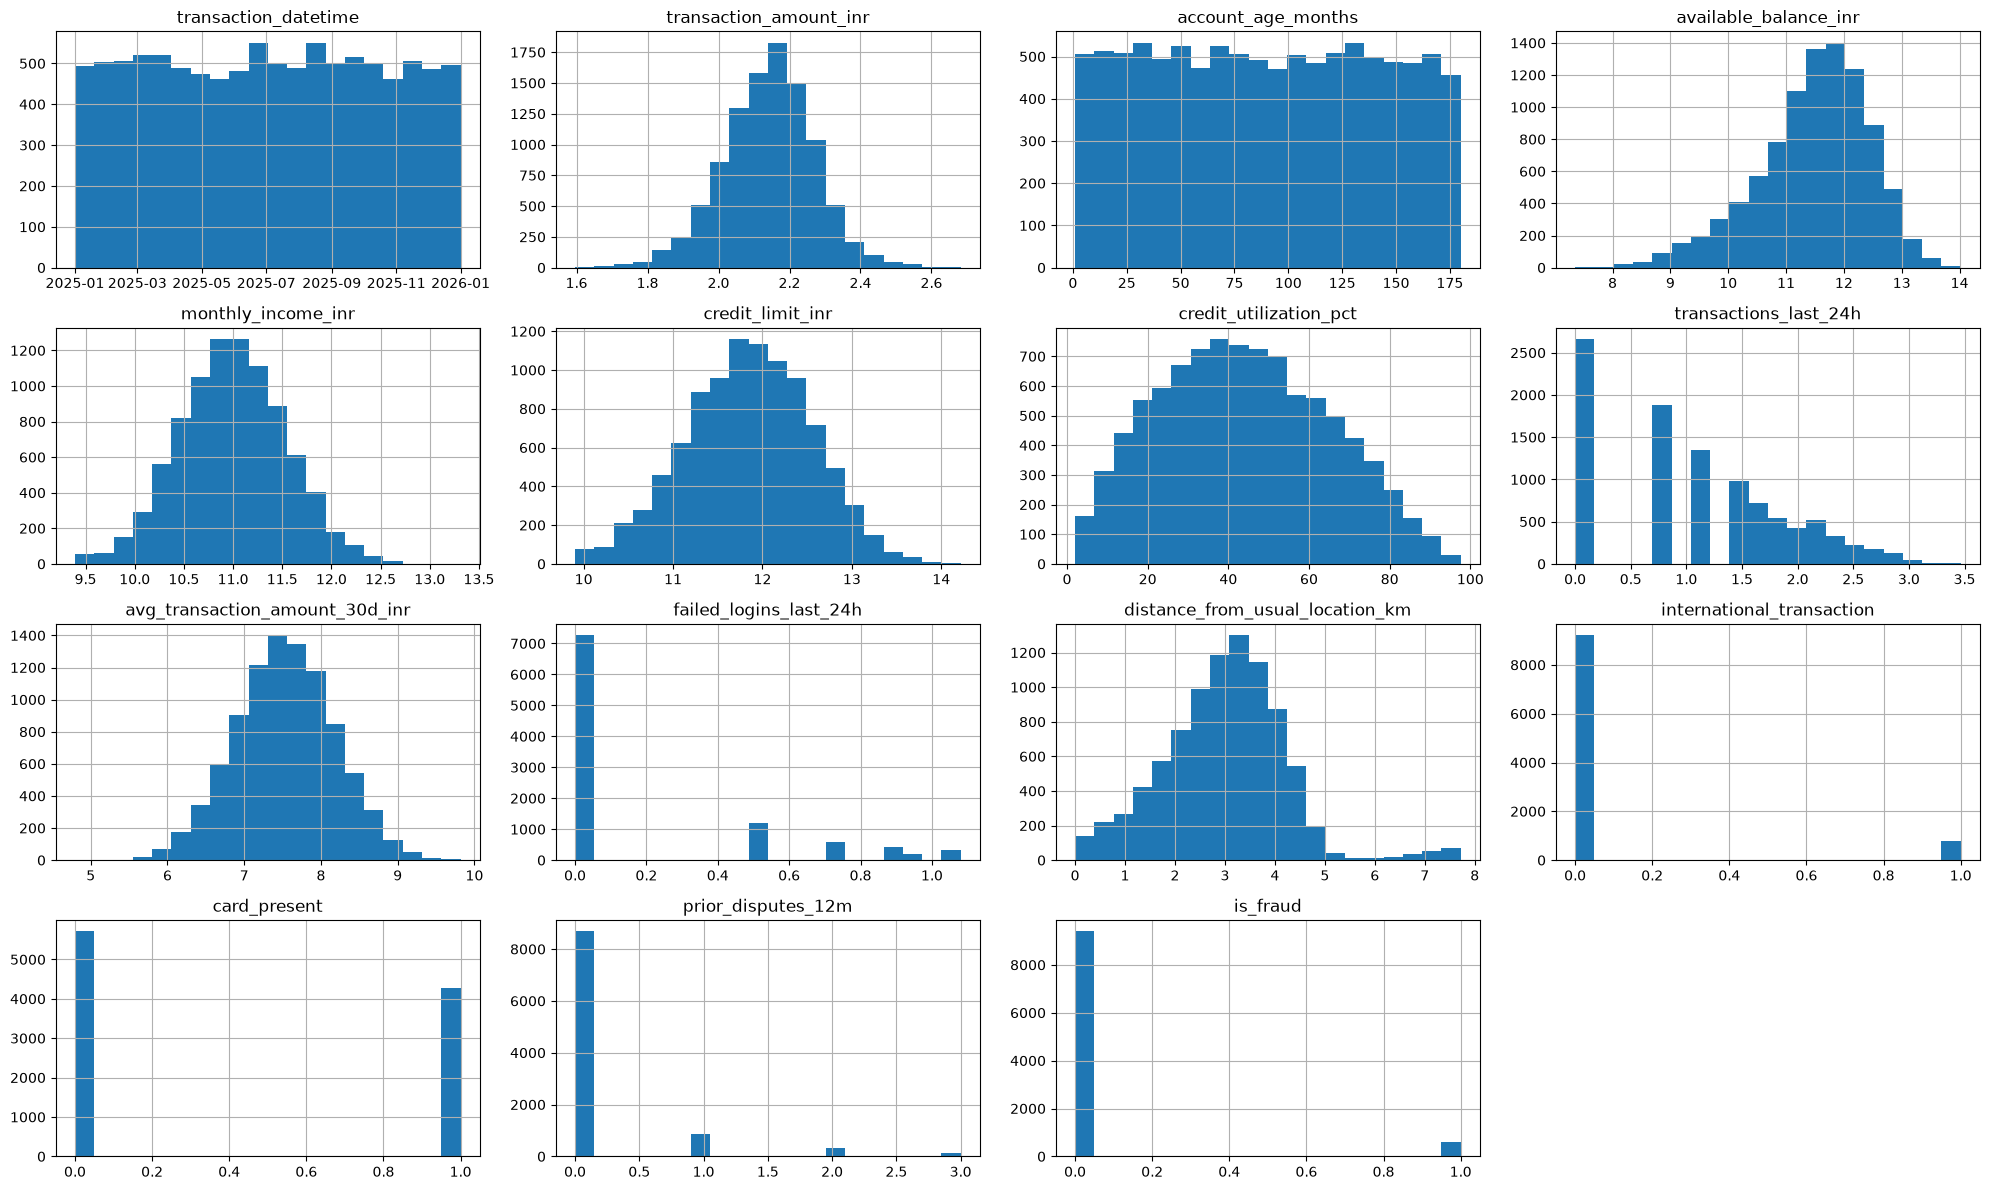

In [13]:
df.hist(figsize=(20,12),bins=20)
plt.tight_layout()
plt.show()

In [14]:
numerical_columns = df.select_dtypes(include = ["number"]).drop(columns=["is_fraud","international_transaction","card_present"]).columns.tolist()
numerical_columns

['transaction_amount_inr',
 'account_age_months',
 'available_balance_inr',
 'monthly_income_inr',
 'credit_limit_inr',
 'credit_utilization_pct',
 'transactions_last_24h',
 'avg_transaction_amount_30d_inr',
 'failed_logins_last_24h',
 'distance_from_usual_location_km',
 'prior_disputes_12m']

In [15]:
for col in numerical_columns:
  df[col] = df[col].fillna(df[col].median())

In [16]:
df.isna().sum()

transaction_id                       0
transaction_datetime                 0
transaction_amount_inr               0
transaction_channel                  0
merchant_category                  430
customer_region                    320
device_type                        525
account_age_months                   0
available_balance_inr                0
monthly_income_inr                   0
credit_limit_inr                     0
credit_utilization_pct               0
transactions_last_24h                0
avg_transaction_amount_30d_inr       0
failed_logins_last_24h               0
distance_from_usual_location_km      0
international_transaction            0
card_present                         0
prior_disputes_12m                   0
is_fraud                             0
dtype: int64

In [17]:
categorical_columns = ["merchant_category","customer_region","device_type"]

In [18]:
for col in categorical_columns:
  df[col] = df[col].fillna(df[col].mode()[0])

In [19]:
df.isna().sum()

transaction_id                     0
transaction_datetime               0
transaction_amount_inr             0
transaction_channel                0
merchant_category                  0
customer_region                    0
device_type                        0
account_age_months                 0
available_balance_inr              0
monthly_income_inr                 0
credit_limit_inr                   0
credit_utilization_pct             0
transactions_last_24h              0
avg_transaction_amount_30d_inr     0
failed_logins_last_24h             0
distance_from_usual_location_km    0
international_transaction          0
card_present                       0
prior_disputes_12m                 0
is_fraud                           0
dtype: int64

In [20]:
df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    94.0
1     6.0
Name: proportion, dtype: float64

<Axes: xlabel='is_fraud'>

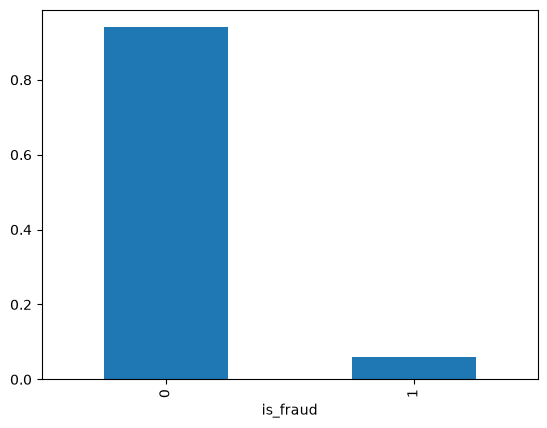

In [21]:
df["is_fraud"].value_counts(normalize=True).plot(kind='bar')

In [22]:
columns_to_encode = ["transaction_channel",	"merchant_category"	,"customer_region",	"device_type"]


In [23]:
df["transaction_channel"].value_counts()

transaction_channel
POS           3595
ecommerce     3258
mobile_app    2176
ATM            971
Name: count, dtype: int64

In [24]:
df["merchant_category"].value_counts()

merchant_category
groceries          2508
restaurants        1433
fuel               1217
utilities          1173
fashion            1167
electronics        1081
travel              863
cash_withdrawal     558
Name: count, dtype: int64

In [25]:
df["customer_region"].value_counts()

customer_region
Mumbai       2086
Bengaluru    1671
Hyderabad    1670
Delhi        1592
Other        1054
Chennai      1047
Pune          880
Name: count, dtype: int64

In [26]:
df["device_type"].value_counts()

device_type
Android          4136
card_terminal    2391
iOS              2225
desktop          1248
Name: count, dtype: int64

In [27]:
for col in columns_to_encode:
  freq = df[col].value_counts(normalize=True)
  df[col] = df[col].map(freq)

In [28]:
df

,transaction_id,transaction_datetime,transaction_amount_inr,transaction_channel,merchant_category,customer_region,device_type,account_age_months,available_balance_inr,monthly_income_inr,credit_limit_inr,credit_utilization_pct,transactions_last_24h,avg_transaction_amount_30d_inr,failed_logins_last_24h,distance_from_usual_location_km,international_transaction,card_present,prior_disputes_12m,is_fraud
0,TXN000001,2025-04-19 13:36:00,2.100055,0.2176,0.2508,0.1670,0.2391,59,10.938898,9.807611,11.101429,60.6,1.609438,7.548967,0.000000,2.646175,1,0,0,0
1,TXN000002,2025-05-23 18:58:00,2.062317,0.0971,0.0558,0.1054,0.2391,129,12.102178,11.072031,11.673498,61.3,0.693147,7.179887,0.741276,2.895912,0,1,0,0
2,TXN000003,2025-11-17 08:55:00,2.123885,0.2176,0.1433,0.2086,0.4136,34,11.061813,11.034011,12.071307,37.7,1.386294,7.834464,0.869742,3.535145,0,0,2,0
3,TXN000004,2025-01-30 04:24:00,2.213921,0.2176,0.1217,0.1671,0.4136,81,9.864464,10.540481,11.866096,15.0,0.693147,7.453695,0.959135,2.397895,0,0,0,0
4,TXN000005,2025-09-03 04:04:00,2.208573,0.3595,0.1217,0.1047,0.2225,10,9.771141,11.266108,11.714275,52.3,0.693147,8.461090,0.000000,3.044522,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,TXN009996,2025-09-29 05:25:00,2.181639,0.2176,0.1217,0.2086,0.2391,32,12.468876,11.135561,12.367481,3.1,0.000000,7.529876,0.000000,3.941582,0,0,0,0
9996,TXN009997,2025-05-06 17:55:00,2.157209,0.3595,0.1173,0.1592,0.4136,15,11.297602,10.993673,11.385063,48.8,0.693147,7.660435,0.741276,4.282206,0,1,0,0
9997,TXN009998,2025-04-16 05:38:00,2.287372,0.2176,0.1173,0.1047,0.4136,133,13.255478,11.880060,13.068921,22.6,1.609438,7.790932,0.000000,3.529297,0,0,0,0
9998,TXN009999,2025-05-01 12:17:00,2.117405,0.3595,0.2508,0.1592,0.2225,32,12.958209,12.247340,13.636737,41.5,1.609438,6.707021,0.000000,3.918005,0,1,0,0


In [29]:
# %pip install "pycaret==3.3.2"

In [30]:
df

,transaction_id,transaction_datetime,transaction_amount_inr,transaction_channel,merchant_category,customer_region,device_type,account_age_months,available_balance_inr,monthly_income_inr,credit_limit_inr,credit_utilization_pct,transactions_last_24h,avg_transaction_amount_30d_inr,failed_logins_last_24h,distance_from_usual_location_km,international_transaction,card_present,prior_disputes_12m,is_fraud
0,TXN000001,2025-04-19 13:36:00,2.100055,0.2176,0.2508,0.1670,0.2391,59,10.938898,9.807611,11.101429,60.6,1.609438,7.548967,0.000000,2.646175,1,0,0,0
1,TXN000002,2025-05-23 18:58:00,2.062317,0.0971,0.0558,0.1054,0.2391,129,12.102178,11.072031,11.673498,61.3,0.693147,7.179887,0.741276,2.895912,0,1,0,0
2,TXN000003,2025-11-17 08:55:00,2.123885,0.2176,0.1433,0.2086,0.4136,34,11.061813,11.034011,12.071307,37.7,1.386294,7.834464,0.869742,3.535145,0,0,2,0
3,TXN000004,2025-01-30 04:24:00,2.213921,0.2176,0.1217,0.1671,0.4136,81,9.864464,10.540481,11.866096,15.0,0.693147,7.453695,0.959135,2.397895,0,0,0,0
4,TXN000005,2025-09-03 04:04:00,2.208573,0.3595,0.1217,0.1047,0.2225,10,9.771141,11.266108,11.714275,52.3,0.693147,8.461090,0.000000,3.044522,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,TXN009996,2025-09-29 05:25:00,2.181639,0.2176,0.1217,0.2086,0.2391,32,12.468876,11.135561,12.367481,3.1,0.000000,7.529876,0.000000,3.941582,0,0,0,0
9996,TXN009997,2025-05-06 17:55:00,2.157209,0.3595,0.1173,0.1592,0.4136,15,11.297602,10.993673,11.385063,48.8,0.693147,7.660435,0.741276,4.282206,0,1,0,0
9997,TXN009998,2025-04-16 05:38:00,2.287372,0.2176,0.1173,0.1047,0.4136,133,13.255478,11.880060,13.068921,22.6,1.609438,7.790932,0.000000,3.529297,0,0,0,0
9998,TXN009999,2025-05-01 12:17:00,2.117405,0.3595,0.2508,0.1592,0.2225,32,12.958209,12.247340,13.636737,41.5,1.609438,6.707021,0.000000,3.918005,0,1,0,0


In [31]:
# from pycaret.classification import *

In [32]:
# exp = setup(data=df, target="is_fraud", train_size=0.8, fold=5, session_id=42,fix_imbalance=True, verbose=False)


In [33]:
# best_model = compare_models(
#     sort="AUC",
#     n_select=3
# )

In [34]:
# print(best_model)

In [35]:
df.head()

,transaction_id,transaction_datetime,transaction_amount_inr,transaction_channel,merchant_category,customer_region,device_type,account_age_months,available_balance_inr,monthly_income_inr,credit_limit_inr,credit_utilization_pct,transactions_last_24h,avg_transaction_amount_30d_inr,failed_logins_last_24h,distance_from_usual_location_km,international_transaction,card_present,prior_disputes_12m,is_fraud
0,TXN000001,2025-04-19 13:36:00,2.100055,0.2176,0.2508,0.1670,0.2391,59,10.938898,9.807611,11.101429,60.6,1.609438,7.548967,0.000000,2.646175,1,0,0,0
1,TXN000002,2025-05-23 18:58:00,2.062317,0.0971,0.0558,0.1054,0.2391,129,12.102178,11.072031,11.673498,61.3,0.693147,7.179887,0.741276,2.895912,0,1,0,0
2,TXN000003,2025-11-17 08:55:00,2.123885,0.2176,0.1433,0.2086,0.4136,34,11.061813,11.034011,12.071307,37.7,1.386294,7.834464,0.869742,3.535145,0,0,2,0
3,TXN000004,2025-01-30 04:24:00,2.213921,0.2176,0.1217,0.1671,0.4136,81,9.864464,10.540481,11.866096,15.0,0.693147,7.453695,0.959135,2.397895,0,0,0,0
4,TXN000005,2025-09-03 04:04:00,2.208573,0.3595,0.1217,0.1047,0.2225,10,9.771141,11.266108,11.714275,52.3,0.693147,8.461090,0.000000,3.044522,0,1,0,0


In [36]:
df["year"] = df["transaction_datetime"].dt.year
df["month"] = df["transaction_datetime"].dt.month
df["day"] = df["transaction_datetime"].dt.day
df["hour"] = df["transaction_datetime"].dt.hour
df["minute"] = df["transaction_datetime"].dt.minute

In [37]:
df = df.drop(columns = ["transaction_datetime"])

LogisticRegression

In [38]:
X = df.drop(columns=["is_fraud","transaction_id"])
y = df["is_fraud"]
X_train, X_test, y_train, y_test = train_test_split(
    X,y,train_size = 0.8,random_state=42 ,stratify=y)

In [39]:
ros = RandomOverSampler(random_state= 42,sampling_strategy="auto")
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

In [40]:
y_train_resampled.value_counts()

is_fraud
0    7520
1    7520
Name: count, dtype: int64

In [41]:
model1 = LogisticRegression()
model1.fit(X_train_resampled,y_train_resampled)

/home/jagdish/Desktop/basics/new_venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [42]:
y_pred1 = model1.predict(X_test)
y_pred1

array([1, 0, 1, ..., 0, 1, 0], shape=(2000,))

In [43]:
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.97      0.63      0.77      1880
           1       0.11      0.68      0.18       120

    accuracy                           0.64      2000
   macro avg       0.54      0.65      0.47      2000
weighted avg       0.92      0.64      0.73      2000



In [44]:
y_prob1 = model1.predict_proba(X_test)[:,1]

In [45]:
fpr1 ,tpr1,thresholds1 = roc_curve(y_test,y_prob1)
auc1 = roc_auc_score(y_test,y_prob1)

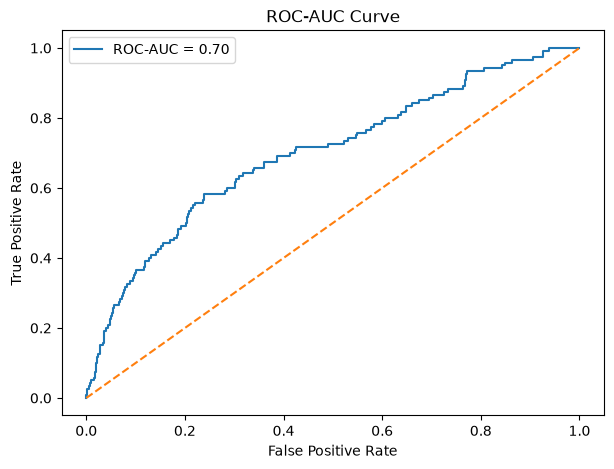

In [46]:
plt.figure(figsize=(7,5))
plt.plot(fpr1,tpr1,label=f"ROC-AUC = {auc1:.2f}")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()

In [47]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

In [48]:
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [49]:
grid.fit(X_train_resampled, y_train_resampled)

/home/jagdish/Desktop/basics/new_venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/jagdish/Desktop/basics/new_venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [50]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 100, 'class_weight': None, 'solver': 'liblinear'}
0.7457121435038478


In [51]:
best_model = grid.best_estimator_

In [52]:
y_pred2 = best_model.predict(X_test)
y_prob2 = best_model.predict_proba(X_test)[:, 1]

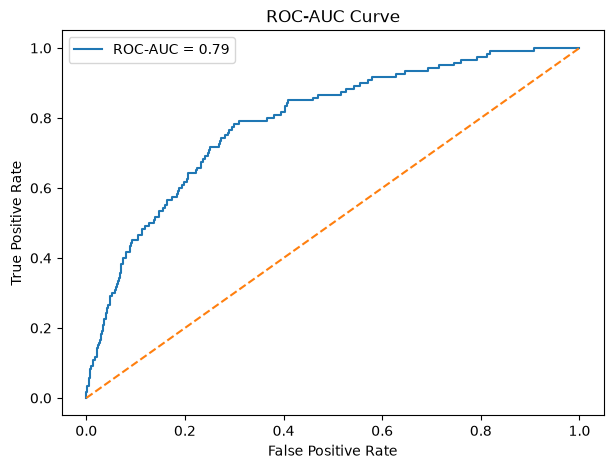

In [53]:
fpr2 ,tpr2,thresholds2 = roc_curve(y_test,y_prob2)
auc2 = roc_auc_score(y_test,y_prob2)
plt.figure(figsize=(7,5))
plt.plot(fpr2,tpr2,label=f"ROC-AUC = {auc2:.2f}")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()

In [54]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.98      0.72      0.83      1880
           1       0.14      0.75      0.24       120

    accuracy                           0.72      2000
   macro avg       0.56      0.73      0.54      2000
weighted avg       0.93      0.72      0.79      2000



In [55]:
results = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],

    "Original Model": [
        accuracy_score(y_test, y_pred1),
        precision_score(y_test, y_pred1),
        recall_score(y_test, y_pred1),
        f1_score(y_test, y_pred1),
        roc_auc_score(y_test, y_prob1)
    ],

    "Tuned Model": [
        accuracy_score(y_test, y_pred2),
        precision_score(y_test, y_pred2),
        recall_score(y_test, y_pred2),
        f1_score(y_test, y_pred2),
        roc_auc_score(y_test, y_prob2)
    ]
}

In [56]:
comparision = pd.DataFrame(results)
print(comparision)

      Metric  Original Model  Tuned Model
0   Accuracy        0.637000     0.719000
1  Precision        0.105469     0.144695
2     Recall        0.675000     0.750000
3         F1        0.182432     0.242588
4    ROC-AUC        0.698825     0.791179


In [59]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Banking_Card_Transaction_Fraud")
print("Connected to:", mlflow.get_tracking_uri())

2026/09/28 09:58:41 INFO mlflow.tracking.fluent: Experiment with name 'Banking_Card_Transaction_Fraud' does not exist. Creating a new experiment.


Connected to: http://127.0.0.1:5000


In [63]:
'''
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

'''

def train_and_log(run_name, C, solver,class_weight):
    with mlflow.start_run(run_name=run_name) as run:
        model = LogisticRegression(
            C=C,
            solver=solver,
            class_weight=class_weight,
            max_iter=1000,
            random_state=42
        )

        model.fit(X_train_resampled, y_train_resampled)
        predicted = model.predict(X_test)
        probabilities = model.predict_proba(X_test)[:, 1]
        scores = {
            "valid_accuracy": accuracy_score(y_test, predicted),
            "valid_precision": precision_score(y_test, predicted, zero_division=0),
            "valid_recall": recall_score(y_test, predicted, zero_division=0),
            "valid_f1": f1_score(y_test, predicted, zero_division=0),
            "valid_roc_auc": roc_auc_score(y_test, probabilities)
        }
        
        mlflow.log_params({"algorithm": "LogisticRegression",
                           "C": str(C),
                           "solver": solver,
                           "class_weight" : class_weight,
                           "max_iter": 1000,
                           "random_state" : 42})
        mlflow.log_metrics(scores)
        mlflow.set_tags({"dataset": "Banking_Card_Transaction_Fraud.csv"})
        mlflow.sklearn.log_model(sk_model=model, name="fraud_detect_pipeline",
                                 input_example=X_train.head(3))
        print("Run:", run_name, "ID:", run.info.run_id)
        print(pd.Series(scores).round(3).to_string())
        return run.info.run_id


In [64]:
best_params = grid.best_params_
run_id = train_and_log(
    run_name="Tuned Logistic Regression",
    C=best_params["C"],
    solver=best_params["solver"],
    class_weight=best_params["class_weight"]
)
print(f"MLflow Run ID for best model: {run_id}")

/home/jagdish/Desktop/basics/new_venv/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/home/jagdish/Desktop/basics/new_venv/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If yo

Run: Tuned Logistic Regression ID: 7c1751c1fe3b4575a6b736517534fc98
valid_accuracy     0.719
valid_precision    0.145
valid_recall       0.750
valid_f1           0.243
valid_roc_auc      0.791
🏃 View run Tuned Logistic Regression at: http://127.0.0.1:5000/#/experiments/1/runs/7c1751c1fe3b4575a6b736517534fc98
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
MLflow Run ID for best model: 7c1751c1fe3b4575a6b736517534fc98


In [65]:
import pickle

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved successfully as best_model.pkl")

Model saved successfully as best_model.pkl


In [ ]:
import streamlit as st
import pandas as pd
import mlflow
from sklearn.linear_model import LogisticRegression
import numpy as np


transaction_channel_map = df['transaction_channel'].value_counts(normalize=True).to_dict()
merchant_category_map = df['merchant_category'].value_counts(normalize=True).to_dict()
customer_region_map = df['customer_region'].value_counts(normalize=True).to_dict()
device_type_map = df['device_type'].value_counts(normalize=True).to_dict()

# Reverse maps for displaying original categories in Streamlit dropdowns
rev_transaction_channel_map = {v: k for k, v in transaction_channel_map.items()}
rev_merchant_category_map = {v: k for k, v in merchant_category_map.items()}
rev_customer_region_map = {v: k for k, v in customer_region_map.items()}
rev_device_type_map = {v: k for k, v in device_type_map.items()}

model = best_model

st.set_page_config(page_title="Fraud Prediction Dashboard", layout="wide")

st.title("Banking Card Transaction Fraud Prediction")
st.markdown("Enter the transaction details to predict if it's a fraudulent activity.")

with st.sidebar:
    st.header("Transaction Details")

    transaction_amount_inr = st.number_input("Transaction Amount (INR) (Log Transformed):", min_value=0.0, value=2.0)
    account_age_months = st.slider("Account Age (Months):", min_value=1, max_value=180, value=50)
    available_balance_inr = st.number_input("Available Balance (INR) (Log Transformed):", min_value=0.0, value=10.0)
    monthly_income_inr = st.number_input("Monthly Income (INR) (Log Transformed):", min_value=0.0, value=10.0)
    credit_limit_inr = st.number_input("Credit Limit (INR) (Log Transformed):", min_value=0.0, value=11.0)
    credit_utilization_pct = st.slider("Credit Utilization (%):", min_value=0.0, max_value=100.0, value=50.0, step=0.1)
    transactions_last_24h = st.number_input("Transactions Last 24h (Log Transformed):", min_value=0.0, value=1.0)
    avg_transaction_amount_30d_inr = st.number_input("Avg. Trans. Amount 30d (INR) (Log Transformed):", min_value=0.0, value=7.0)
    failed_logins_last_24h = st.number_input("Failed Logins Last 24h (Log Transformed):", min_value=0.0, value=0.0)
    distance_from_usual_location_km = st.number_input("Distance from Usual Location (KM) (Log Transformed):", min_value=0.0, value=3.0)
    international_transaction = st.selectbox("International Transaction:", [0, 1], format_func=lambda x: "Yes" if x == 1 else "No")
    card_present = st.selectbox("Card Present:", [0, 1], format_func=lambda x: "Yes" if x == 1 else "No")
    prior_disputes_12m = st.slider("Prior Disputes (Last 12 Months):", min_value=0, max_value=3, value=0)

    st.subheader("Categorical Features")
    selected_transaction_channel = st.selectbox("Transaction Channel:", list(transaction_channel_map.keys()))
    selected_merchant_category = st.selectbox("Merchant Category:", list(merchant_category_map.keys()))
    selected_customer_region = st.selectbox("Customer Region:", list(customer_region_map.keys()))
    selected_device_type = st.selectbox("Device Type:", list(device_type_map.keys()))

    st.subheader("Transaction Date/Time Components")
    year = st.number_input("Year:", min_value=2020, max_value=2030, value=2025)
    month = st.slider("Month:", min_value=1, max_value=12, value=7)
    day = st.slider("Day:", min_value=1, max_value=31, value=15)
    hour = st.slider("Hour:", min_value=0, max_value=23, value=12)
    minute = st.slider("Minute:", min_value=0, max_value=59, value=30)

if st.button("Predict Fraud"):
    transaction_channel_freq = transaction_channel_map.get(selected_transaction_channel, 0.0) # Default to 0 if not found
    merchant_category_freq = merchant_category_map.get(selected_merchant_category, 0.0)
    customer_region_freq = customer_region_map.get(selected_customer_region, 0.0)
    device_type_freq = device_type_map.get(selected_device_type, 0.0)

    input_data = pd.DataFrame([[
        transaction_amount_inr,
        transaction_channel_freq,
        merchant_category_freq,
        customer_region_freq,
        device_type_freq,
        account_age_months,
        available_balance_inr,
        monthly_income_inr,
        credit_limit_inr,
        credit_utilization_pct,
        transactions_last_24h,
        avg_transaction_amount_30d_inr,
        failed_logins_last_24h,
        distance_from_usual_location_km,
        international_transaction,
        card_present,
        prior_disputes_12m,
        year,
        month,
        day,
        hour,
        minute
    ]], columns=X_train.columns) # Use X_train columns to ensure correct order

    prediction = model.predict(input_data)
    prediction_proba = model.predict_proba(input_data)[:, 1]

    st.subheader("Prediction Result:")
    if prediction[0] == 1:
        st.error(f"**Fraudulent Transaction Detected!** (Probability: {prediction_proba[0]:.2f})")
    else:
        st.success(f"**Not Fraudulent.** (Probability: {prediction_proba[0]:.2f})")

    st.write("--- ")
    st.write("**Input Features:**")
    st.dataframe(input_data)

2026-09-28 10:11:02.809 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 10:11:02.810 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 10:11:02.858 
  command:

    streamlit run /home/jagdish/Desktop/basics/new_venv/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-09-28 10:11:02.859 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 10:11:02.859 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 10:11:02.860 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 10:11:02.860 Thread 'MainThread': missing ScriptRunContext! This warning 